In [4]:
import torch
import tiktoken
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch import nn

In [5]:
texto_ejemplo: str = "Your journey starts with one step."
texto_ejemplo

'Your journey starts with one step.'

In [6]:
tokenizer = tiktoken.get_encoding(encoding_name="gpt2")
tokens = tokenizer.encode(texto_ejemplo)
tokens

[7120, 7002, 4940, 351, 530, 2239, 13]

In [7]:
tamanio_vocabulario = tokenizer.n_vocab
tamanio_vocabulario

50257

In [8]:
embedding_layer = torch.nn.Embedding(num_embeddings=tamanio_vocabulario, embedding_dim=3)
embedding_layer.weight.shape

torch.Size([50257, 3])

In [9]:
tensor_tokens = torch.tensor(tokens).expand((1, len(tokens)))
print(tensor_tokens.shape)
tensor_tokens

torch.Size([1, 7])


tensor([[7120, 7002, 4940,  351,  530, 2239,   13]])

In [10]:
tokens_embeddings = embedding_layer(tensor_tokens)
print(tokens_embeddings.shape)
tokens_embeddings

torch.Size([1, 7, 3])


tensor([[[ 0.9293, -1.7528, -0.2413],
         [-0.4071,  1.2178,  0.8899],
         [ 1.7603,  0.3734,  0.9744],
         [ 1.0978, -0.7794,  0.5715],
         [-0.6207,  0.7682, -0.7463],
         [-0.7808, -2.1061, -0.7302],
         [ 1.5627,  1.6014,  0.4812]]], grad_fn=<EmbeddingBackward0>)

In [11]:
# Sé que esto no es eficiente pero es a modo didáctico
matriz_atencion = []
for batch in range(tokens_embeddings.shape[0]):
    for i in range(tokens_embeddings.shape[1]):
        for j in range(tokens_embeddings.shape[1]):
            matriz_atencion.append(torch.dot(tokens_embeddings[batch, i, :].flatten(), tokens_embeddings[batch, j, :].flatten()).detach().numpy())

matriz_atencion = np.array(matriz_atencion).reshape(tokens_embeddings.shape[0], tokens_embeddings.shape[1], tokens_embeddings.shape[1])
matriz_atencion

array([[[ 3.9941072 , -2.7274938 ,  0.74632895,  2.2484486 ,
         -1.7432696 ,  3.1421635 , -1.4708724 ],
        [-2.7274938 ,  2.4406555 ,  0.6051978 , -0.8874517 ,
          0.52402765, -2.8966842 ,  1.7422537 ],
        [ 0.74632895,  0.6051978 ,  4.187522  ,  2.1983414 ,
         -1.5329199 , -2.872253  ,  3.8176818 ],
        [ 2.2484486 , -0.8874517 ,  2.1983414 ,  2.1392384 ,
         -1.7065914 ,  0.36702386,  0.7424718 ],
        [-1.7432696 ,  0.52402765, -1.5329199 , -1.7065914 ,
          1.5322849 , -0.58836794, -0.09888729],
        [ 3.1421635 , -2.8966842 , -2.872253  ,  0.36702386,
         -0.58836794,  5.578434  , -4.944258  ],
        [-1.4708724 ,  1.7422537 ,  3.8176818 ,  0.7424718 ,
         -0.09888729, -4.944258  ,  5.238145  ]]], dtype=float32)

In [12]:
# Para normalizar los valores, podemos utilizar Softmax donde el objetivo es que cada 
# fila de la matriz sume 1 (es decir, queremos saber cómo distribuye la atención un
# token hacia todos los demás tokens).
# matriz_atencion.shape -> (batch, tokens_embeddings, tokens_embeddings) -> (batch, filas, columnas)
matriz_atencion_normalizada = torch.softmax(torch.tensor(matriz_atencion), dim=-1)
matriz_atencion_normalizada

tensor([[[6.0656e-01, 7.3067e-04, 2.3571e-02, 1.0586e-01, 1.9551e-03,
          2.5875e-01, 2.5672e-03],
         [3.0778e-03, 5.4043e-01, 8.6220e-02, 1.9380e-02, 7.9498e-02,
          2.5987e-03, 2.6880e-01],
         [1.6931e-02, 1.4702e-02, 5.2865e-01, 7.2323e-02, 1.7330e-03,
          4.5409e-04, 3.6521e-01],
         [3.0446e-01, 1.3232e-02, 2.8958e-01, 2.7296e-01, 5.8329e-03,
          4.6392e-02, 6.7530e-02],
         [2.0949e-02, 2.0223e-01, 2.5854e-02, 2.1732e-02, 5.5428e-01,
          6.6487e-02, 1.0847e-01],
         [7.9861e-02, 1.9041e-04, 1.9512e-04, 4.9786e-03, 1.9151e-03,
          9.1284e-01, 2.4572e-05],
         [9.4625e-04, 2.3521e-02, 1.8741e-01, 8.6547e-03, 3.7312e-03,
          2.9345e-05, 7.7571e-01]]])

In [13]:
matriz_atencion_normalizada.sum(dim=-1)

tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000]])

In [14]:
tokens_embeddings.shape

torch.Size([1, 7, 3])

In [15]:
tokens_embeddings.transpose(1,2).shape

torch.Size([1, 3, 7])

In [16]:
# Una forma más eficiente es hacer el producto matricial de la traspuesta 
matriz_atencion_eficiente = tokens_embeddings@tokens_embeddings.transpose(1,2)
matriz_atencion_eficiente = matriz_atencion_eficiente.detach().numpy()
matriz_atencion_eficiente

array([[[ 3.9941072 , -2.7274938 ,  0.74632895,  2.2484486 ,
         -1.7432696 ,  3.1421635 , -1.4708724 ],
        [-2.7274938 ,  2.4406555 ,  0.6051978 , -0.8874517 ,
          0.52402765, -2.8966842 ,  1.7422537 ],
        [ 0.74632895,  0.6051978 ,  4.187522  ,  2.1983414 ,
         -1.5329199 , -2.872253  ,  3.8176818 ],
        [ 2.2484486 , -0.8874517 ,  2.1983414 ,  2.1392384 ,
         -1.7065914 ,  0.36702386,  0.7424718 ],
        [-1.7432696 ,  0.52402765, -1.5329199 , -1.7065914 ,
          1.5322849 , -0.58836794, -0.09888729],
        [ 3.1421635 , -2.8966842 , -2.872253  ,  0.36702386,
         -0.58836794,  5.578434  , -4.944258  ],
        [-1.4708724 ,  1.7422537 ,  3.8176818 ,  0.7424718 ,
         -0.09888729, -4.944258  ,  5.238145  ]]], dtype=float32)

In [17]:
np.array_equal(matriz_atencion, matriz_atencion_eficiente)

True

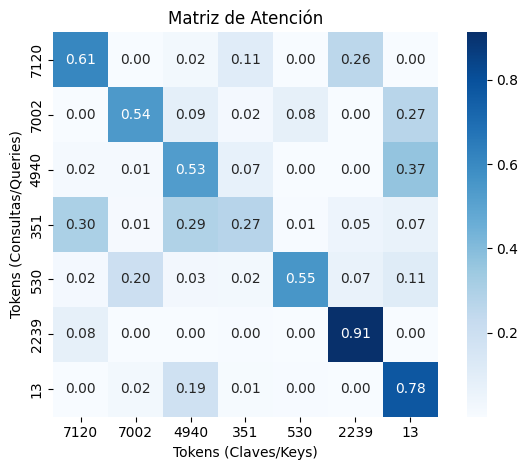

In [18]:
sns.heatmap(
    matriz_atencion_normalizada[0,:,:], 
    annot=True,                    
    fmt=".2f",                     
    cmap="Blues",                 
    xticklabels=tokens,    
    yticklabels=tokens,   
    square=True,                  
    cbar=True                    
)

plt.title("Matriz de Atención")
plt.xlabel("Tokens (Claves/Keys)")
plt.ylabel("Tokens (Consultas/Queries)")
plt.tight_layout()
plt.show()

In [19]:
tokens_embeddings.shape, matriz_atencion_normalizada.shape

(torch.Size([1, 7, 3]), torch.Size([1, 7, 7]))

In [20]:
# Tenemos que matriz_atencion_normalizada es -> (1, 7, 7) -> (batch, num_tokens, num_tokens)
# y tokens_embedding es -> (1, 7, 3)
# podemos hacer (1, 7, 7) @ (1, 7, 3) -> (1, 7, 3)
hidden_embedding = matriz_atencion_normalizada @ tokens_embeddings
hidden_embedding.shape

torch.Size([1, 7, 3])

In [21]:
hidden_embedding

tensor([[[ 0.5219, -1.6753, -0.2514],
         [ 0.3246,  1.1559,  0.6434],
         [ 1.5890,  0.7145,  0.7395],
         [ 1.1527, -0.6073,  0.3707],
         [-0.2199,  0.6617, -0.1974],
         [-0.6339, -2.0646, -0.6840],
         [ 1.5406,  1.3352,  0.5788]]], grad_fn=<UnsafeViewBackward0>)

In [ ]:
class SelfAttention(nn.Module):

    def __init__(self, d_in: int, d_out: int, bias: bool=False) -> None:
        
        super().__init__()

        self.query = nn.Linear(in_features=d_in, out_features=d_out, bias=bias)
        self.key = nn.Linear(in_features=d_in, out_features=d_out, bias=bias)
        self.value = nn.Linear(in_features=d_in, out_features=d_out, bias=bias)

    def forward(self, input_tensor: torch.Tensor) -> torch.Tensor:

        query_tensor = self.query(input_tensor)
        key_tensor = self.key(input_tensor)
        value_tensor = self.value(input_tensor)

        # input_tensor.shape -> (batch, num_embdeddings, d_in)
        # query_tensor -> (batch, input_tensor.shape[1], d_out)
        # key_tensor -> (batch, input_tensor.shape[1], d_out)
        # ke_tensor.transpose(-2, -1) -> (batch, d_out, input_tensor.shape[1])
        # attention_scores -> (batch, input_tensor.shape[1], input_tensor.shape[1])
        attention_scores = query_tensor @ key_tensor.transpose(-2, -1)

        dk = torch.tensor(key_tensor.shape[-1])
        normalized_attention_scores = torch.softmax(attention_scores / torch.sqrt(dk), dim=-1)

        return normalized_attention_scores @ value_tensor

In [32]:
tokens_embeddings.shape

torch.Size([1, 7, 3])

In [33]:
self_attention_layer = SelfAttention(d_in=tokens_embeddings.shape[-1], d_out=3)
output_self_attention = self_attention_layer(tokens_embeddings)
output_self_attention

tensor([[[-0.1165, -0.0227,  0.2045],
         [-0.2707, -0.0845,  0.1663],
         [-0.3446, -0.1151,  0.1304],
         [-0.2395, -0.0714,  0.1633],
         [-0.0826, -0.0099,  0.2420],
         [ 0.0266,  0.0297,  0.2476],
         [-0.3301, -0.1075,  0.1537]]], grad_fn=<UnsafeViewBackward0>)

In [ ]:
# LAs inicializaciones van a cambiar con cada instancia de la clase
self_attention_layer_2 = SelfAttention(d_in=tokens_embeddings.shape[-1], d_out=3)
output_self_attention_2 = self_attention_layer_2(tokens_embeddings)
output_self_attention_2

tensor([[[ 0.1250, -0.0531, -0.0454],
         [ 0.1221, -0.0859, -0.0805],
         [ 0.1838, -0.0216,  0.0033],
         [ 0.1508, -0.0494, -0.0344],
         [ 0.0802, -0.0745, -0.0814],
         [ 0.0651, -0.1041, -0.1160],
         [ 0.1746, -0.0109,  0.0117]]], grad_fn=<UnsafeViewBackward0>)

In [ ]:
# Podemos copiar los pesos de una instancia a otra de la siguiente forma
self_attention_layer_2 = SelfAttention(d_in=tokens_embeddings.shape[-1], d_out=3)
self_attention_layer_2.load_state_dict(self_attention_layer.state_dict())
output_self_attention_2 = self_attention_layer_2(tokens_embeddings)
output_self_attention_2

tensor([[[-0.1165, -0.0227,  0.2045],
         [-0.2707, -0.0845,  0.1663],
         [-0.3446, -0.1151,  0.1304],
         [-0.2395, -0.0714,  0.1633],
         [-0.0826, -0.0099,  0.2420],
         [ 0.0266,  0.0297,  0.2476],
         [-0.3301, -0.1075,  0.1537]]], grad_fn=<UnsafeViewBackward0>)